In [1]:
import json
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

In [2]:
def extract_json(text):
    try:
        return json.loads(text)
    except:
        return None

def clean_to_float(x):
    try:
        x = str(x)
        x = re.sub(r"[^0-9.\-]", "", x)
        if x in ["", ".", "-"]:
            return np.nan
        return float(x)
    except:
        return np.nan        

In [3]:
with open("./Data/www.cnbc.com-2.har", "r", encoding="utf-8") as f:
    har = json.load(f)

In [4]:
rows = []

for entry in har["log"]["entries"]:

    req = entry.get("request", {})
    res = entry.get("response", {})
    content = res.get("content", {})

    rows.append({
        "url": req.get("url"),
        "method": req.get("method"),
        "status": res.get("status"),
        "time": entry.get("time"),
        "mime": content.get("mimeType"),
        "body": content.get("text")
    })
    
df = pd.DataFrame(rows)
df.head()

,url,method,status,time,mime,body
0,https://dpm.demdex.net/optOutStatus?d_visid_ve...,GET,200,2244.215,application/json,"{\n ""d_optout"" : [ ],\n ""d_ottl"" : 7200\n}"
1,https://cdn.cookielaw.org/consent/01980fea-4b6...,GET,200,4.039,application/json,"{""CookieSPAEnabled"":true,""CookieSameSiteNoneEn..."
2,https://cdn.cookielaw.org/scripttemplates/2026...,GET,200,3.814,application/json,"{\n ""hbbtv.js"": ""sha384-uCnK95b3jS2qCJimbRT2v..."
3,https://cdn.cookielaw.org/consent/01980fea-4b6...,GET,200,23.327,application/json,"{""DomainData"":{""pclifeSpanYr"":""Year"",""pclifeSp..."
4,https://cdn.cookielaw.org/scripttemplates/2026...,GET,200,4.365,application/json,"\n {\n ""name"": ""otFl..."


In [8]:
df[df["url"].str.contains("https://webql-redesign.cnbcfm.com/graphql", na=False)]

,url,method,status,time,mime,body
11,https://webql-redesign.cnbcfm.com/graphql?oper...,GET,200,333.434,application/json,"{""data"":{""newsAlert"":{""breakingNews"":null,""wat..."
12,https://webql-redesign.cnbcfm.com/graphql?oper...,GET,200,751.040,application/json,"{""data"":{""search"":{""results"":[{""datePublished""..."
13,https://webql-redesign.cnbcfm.com/graphql?oper...,GET,200,329.518,application/json,"{""data"":{""showsSchedule"":{""scheduleStartTime"":..."
15,https://webql-redesign.cnbcfm.com/graphql?oper...,GET,200,758.229,application/json,"{""data"":{""search"":{""results"":[{""datePublished""..."
17,https://webql-redesign.cnbcfm.com/graphql?oper...,GET,200,673.252,application/json,"{""data"":{""chartData"":{""symbol"":""US10Y"",""timeRa..."
56,https://webql-redesign.cnbcfm.com/graphql?oper...,GET,200,126.043,application/json,"{""data"":{""newsAlert"":{""breakingNews"":null,""wat..."
57,https://webql-redesign.cnbcfm.com/graphql?oper...,GET,200,555.136,application/json,"{""data"":{""chartData"":{""symbol"":""US10Y"",""timeRa..."
79,https://webql-redesign.cnbcfm.com/graphql?oper...,GET,200,354.602,application/json,"{""data"":{""newsAlert"":{""breakingNews"":null,""wat..."
80,https://webql-redesign.cnbcfm.com/graphql?oper...,GET,200,444.364,application/json,"{""data"":{""chartData"":{""symbol"":""US10Y"",""timeRa..."
82,https://webql-redesign.cnbcfm.com/graphql?oper...,GET,200,566.712,application/json,"{""data"":{""chartData"":{""symbol"":""US10Y"",""timeRa..."


In [9]:
chart_df = df[df["url"].str.contains("https://webql-redesign.cnbcfm.com/graphql", na=False)]
chart_df = chart_df[chart_df["body"].str.contains("chartData", na=False)]
chart_df = chart_df[chart_df["body"].str.contains('"symbol":"US10Y","timeRange":"1D"', na=False)]
chart_df

,url,method,status,time,mime,body
57,https://webql-redesign.cnbcfm.com/graphql?oper...,GET,200,555.136,application/json,"{""data"":{""chartData"":{""symbol"":""US10Y"",""timeRa..."


In [11]:
chart_df.iloc[0]['url']

'https://webql-redesign.cnbcfm.com/graphql?operationName=getQuoteChartData&variables=%7B%22symbol%22%3A%22US10Y%22%2C%22timeRange%22%3A%221D%22%7D&extensions=%7B%22persistedQuery%22%3A%7B%22version%22%3A1%2C%22sha256Hash%22%3A%229e1670c29a10707c417a1efd327d4b2b1d456b77f1426e7e84fb7d399416bb6b%22%7D%7D'

In [185]:
data1 = extract_json(chart_df.iloc[0]["body"])
print(f"data1 : {data1.keys()}")
data2 = data1['data']
print(f"data2 : {data2.keys()}")
data3 = data2['chartData']
print(f"data3 : {data3.keys()}")
data = data3['priceBars']
print(f"data : {data[0].keys()}")

data1 : dict_keys(['data'])
data2 : dict_keys(['chartData'])
data3 : dict_keys(['symbol', 'timeRange', 'allSymbols', 'priceBars', '__typename'])
data : dict_keys(['open', 'high', 'low', 'close', 'volume', 'tradeTime', 'tradeTimeinMills', '__typename'])


In [186]:
print(data3["allSymbols"])

[{'symbol': 'US10Y', 'name': 'U.S. 10 Year Treasury', 'shortName': 'US 10-YR', 'last': '4.447%', '__typename': 'QuoteFields'}]


In [187]:
mydf = pd.DataFrame(data)
mydf.head()

,open,high,low,close,volume,tradeTime,tradeTimeinMills,__typename
0,4.4750,4.4770,4.4750,4.4750,0,20260527091600,1779887760000,priceBarType
1,4.4750,4.4750,4.4750,4.4750,0,20260527091700,1779887820000,priceBarType
2,4.4730,4.4750,4.4730,4.4750,0,20260527091800,1779887880000,priceBarType
3,4.4750,4.4750,4.4750,4.4750,0,20260527091900,1779887940000,priceBarType
4,4.4750,4.4770,4.4730,4.4770,0,20260527092000,1779888000000,priceBarType


In [188]:
cols = mydf.columns
mydf.drop(columns=mydf.columns[-1], inplace=True)

df_clean = mydf.copy()

for col in df_clean.columns:
    if col != cols[6] or col != cols[7]:  # exclude time
        df_clean[col] = df_clean[col].apply(clean_to_float)

time_col = cols[6]

df_clean[time_col] = pd.to_datetime(
    df_clean[time_col].astype(float),
    unit="ms"
)

df_clean["close"] = df_clean["close"].astype(float)
df_clean["open"] = df_clean["open"].astype(float)
df_clean["high"] = df_clean["high"].astype(float)
df_clean["low"] = df_clean["low"].astype(float)
df_clean = df_clean.sort_values(time_col)


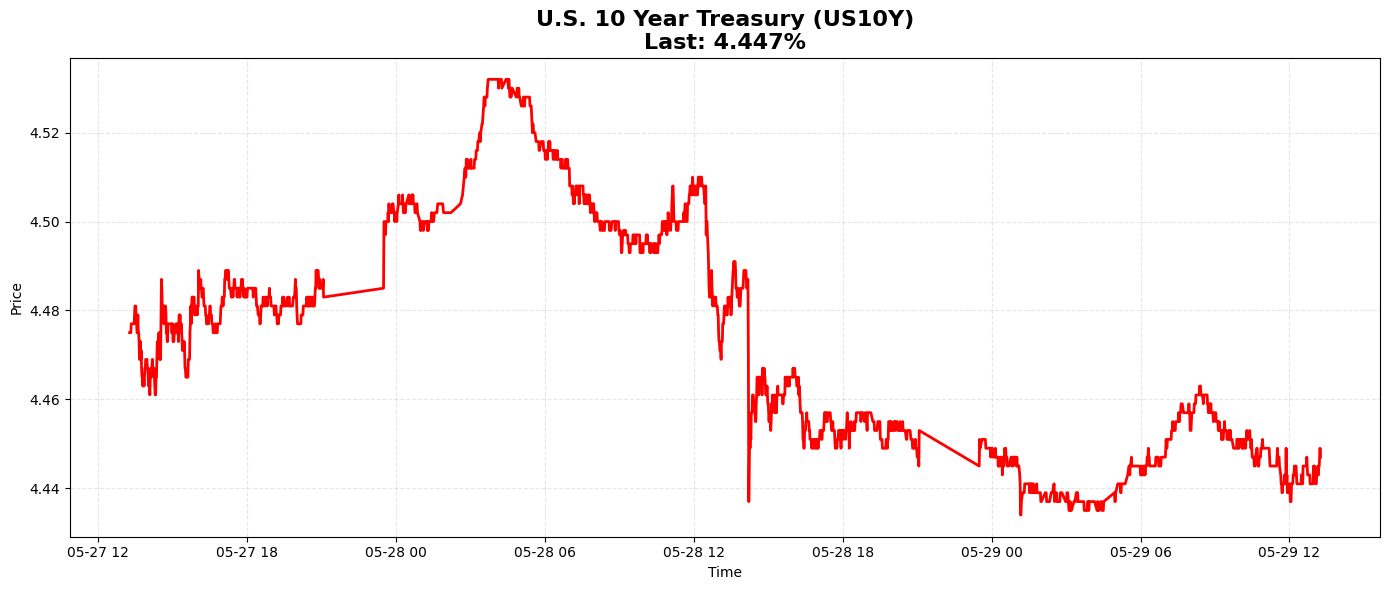

In [189]:
close_col = cols[3]

symbol_info = data3["allSymbols"][0]
symbol = symbol_info["symbol"]
name = symbol_info["name"]
last = symbol_info["last"]

color = "green" if df_clean[close_col].iloc[-1] > df_clean[close_col].iloc[0] else "red"

plt.figure(figsize=(14, 6))

plt.plot(
    df_clean[time_col],
    df_clean[close_col],
    color=color,
    linewidth=2
)

plt.title(f"{name} ({symbol})\nLast: {last}", fontsize=16, fontweight="bold")
plt.xlabel("Time")
plt.ylabel("Price")

plt.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()